<a href="https://colab.research.google.com/github/dandanakaka/DeepLearningLab/blob/main/DeepLearningLab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Display the shapes of the training and testing data
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Define class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("CIFAR-10 dataset loaded and shapes displayed. Class names defined.")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1704s 10us/step
Shape of x_train: (50000, 32, 32, 3)
Shape of y_train: (50000, 1)
Shape of x_test: (10000, 32, 32, 3)
Shape of y_test: (10000, 1)
CIFAR-10 dataset loaded and shapes displayed. Class names defined.


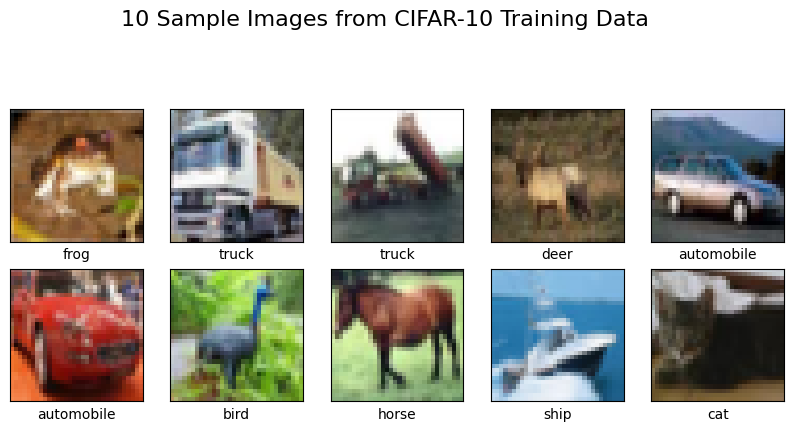

Displayed 10 sample images with their class labels.


In [3]:
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.suptitle('10 Sample Images from CIFAR-10 Training Data', fontsize=16)
plt.show()

print("Displayed 10 sample images with their class labels.")

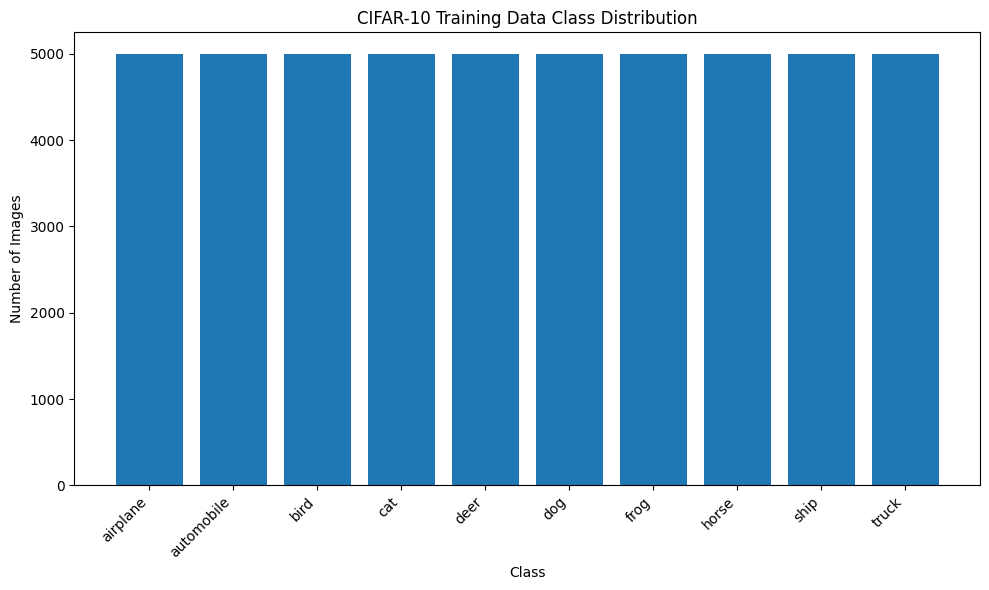

Class distribution plot displayed.


In [5]:
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 6))
plt.bar(class_names, counts)
plt.title('CIFAR-10 Training Data Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Class distribution plot displayed.")

In [9]:
import tensorflow as tf

# 1. Select a sample image and reshape it to add a batch dimension
sample_image = x_train[0]
sample_image_batch = tf.expand_dims(sample_image, axis=0)

# Convert the image to float32 and normalize it
sample_image_batch = tf.cast(sample_image_batch, tf.float32) / 255.0

print(f"Original sample image shape: {sample_image.shape}")
print(f"Sample image with batch dimension shape: {sample_image_batch.shape}")
print(f"Sample image batch dtype after conversion: {sample_image_batch.dtype}")

# 2. Define three convolution kernels of sizes 3x3, 5x5, and 7x7
# The number of input channels is 3 (for RGB images), and let's assume 1 output filter for simplicity
kernel_3x3 = tf.random.normal([3, 3, 3, 1]) # height, width, in_channels, out_channels
kernel_5x5 = tf.random.normal([5, 5, 3, 1])
kernel_7x7 = tf.random.normal([7, 7, 3, 1])

print(f"Kernel 3x3 shape: {kernel_3x3.shape}")
print(f"Kernel 5x5 shape: {kernel_5x5.shape}")
print(f"Kernel 7x7 shape: {kernel_7x7.shape}")

Original sample image shape: (32, 32, 3)
Sample image with batch dimension shape: (1, 32, 32, 3)
Sample image batch dtype after conversion: <dtype: 'float32'>
Kernel 3x3 shape: (3, 3, 3, 1)
Kernel 5x5 shape: (5, 5, 3, 1)
Kernel 7x7 shape: (7, 7, 3, 1)


In [12]:
conv_3x3_output = tf.nn.conv2d(input=sample_image_batch, filters=kernel_3x3, strides=[1, 1, 1, 1], padding='VALID')
conv_5x5_output = tf.nn.conv2d(input=sample_image_batch, filters=kernel_5x5, strides=[1, 1, 1, 1], padding='VALID')
conv_7x7_output = tf.nn.conv2d(input=sample_image_batch, filters=kernel_7x7, strides=[1, 1, 1, 1], padding='VALID')

print(f"Output feature map shape with 3x3 kernel: {conv_3x3_output.shape}")
print(f"Output feature map shape with 5x5 kernel: {conv_5x5_output.shape}")
print(f"Output feature map shape with 7x7 kernel: {conv_7x7_output.shape}")

Output feature map shape with 3x3 kernel: (1, 30, 30, 1)
Output feature map shape with 5x5 kernel: (1, 28, 28, 1)
Output feature map shape with 7x7 kernel: (1, 26, 26, 1)


In [13]:
kernel_3x3 = tf.random.normal([3, 3, 3, 1]) # Re-using 3x3 kernel or defining a new one for clarity

# Stride 1, Padding 'VALID'
conv_s1_v_output = tf.nn.conv2d(input=sample_image_batch, filters=kernel_3x3, strides=[1, 1, 1, 1], padding='VALID')
print(f"Output shape (Stride=1, Padding='VALID'): {conv_s1_v_output.shape}")

# Stride 1, Padding 'SAME'
conv_s1_s_output = tf.nn.conv2d(input=sample_image_batch, filters=kernel_3x3, strides=[1, 1, 1, 1], padding='SAME')
print(f"Output shape (Stride=1, Padding='SAME'): {conv_s1_s_output.shape}")

# Stride 2, Padding 'VALID'
conv_s2_v_output = tf.nn.conv2d(input=sample_image_batch, filters=kernel_3x3, strides=[1, 2, 2, 1], padding='VALID')
print(f"Output shape (Stride=2, Padding='VALID'): {conv_s2_v_output.shape}")

# Stride 2, Padding 'SAME'
conv_s2_s_output = tf.nn.conv2d(input=sample_image_batch, filters=kernel_3x3, strides=[1, 2, 2, 1], padding='SAME')
print(f"Output shape (Stride=2, Padding='SAME'): {conv_s2_s_output.shape}")

Output shape (Stride=1, Padding='VALID'): (1, 30, 30, 1)
Output shape (Stride=1, Padding='SAME'): (1, 32, 32, 1)
Output shape (Stride=2, Padding='VALID'): (1, 15, 15, 1)
Output shape (Stride=2, Padding='SAME'): (1, 16, 16, 1)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Shape of feature maps: (1, 30, 30, 8)


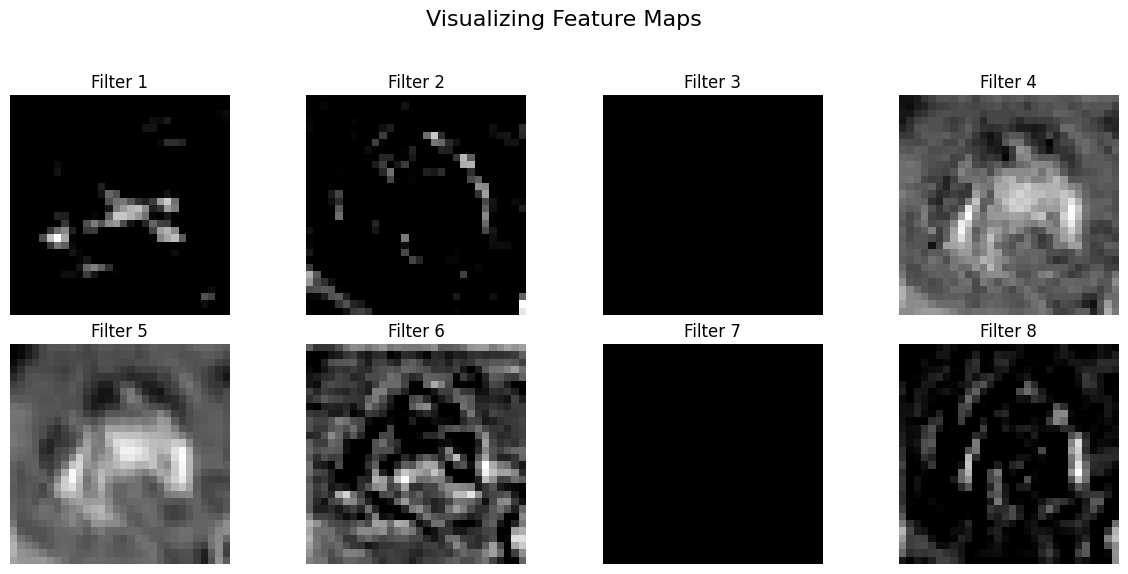

Displayed 8 feature maps.


In [15]:
import matplotlib.pyplot as plt

# 1. Define a convolution layer
conv_layer = tf.keras.layers.Conv2D(
    filters=8,        # Number of filters
    kernel_size=(3, 3), # Kernel size
    activation='relu',  # Activation function
    input_shape=(32, 32, 3) # Input shape (height, width, channels)
)

# Reshape sample_image_batch for Conv2D layer if necessary (Conv2D expects (batch, h, w, c))
# sample_image_batch is already (1, 32, 32, 3)

# 2. Apply the convolution layer to the sample_image_batch
feature_maps = conv_layer(sample_image_batch)

print(f"Shape of feature maps: {feature_maps.shape}")

# 3. Iterate through the first 8 feature maps and display them
plt.figure(figsize=(12, 6))
plt.suptitle('Visualizing Feature Maps', fontsize=16)

for i in range(8):
    plt.subplot(2, 4, i + 1) # Arrange in 2 rows, 4 columns
    plt.imshow(feature_maps[0, :, :, i], cmap='gray') # Extract and display i-th filter's output
    plt.title(f'Filter {i + 1}')
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print("Displayed 8 feature maps.")

In [17]:
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

print(f"x_train_normalized shape: {x_train_normalized.shape}")
print(f"x_train_normalized dtype: {x_train_normalized.dtype}")
print(f"x_train_normalized min value: {x_train_normalized.min()}")
print(f"x_train_normalized max value: {x_train_normalized.max()}\n")

print(f"x_test_normalized shape: {x_test_normalized.shape}")
print(f"x_test_normalized dtype: {x_test_normalized.dtype}")
print(f"x_test_normalized min value: {x_test_normalized.min()}")
print(f"x_test_normalized max value: {x_test_normalized.max()}")

x_train_normalized shape: (50000, 32, 32, 3)
x_train_normalized dtype: float32
x_train_normalized min value: 0.0
x_train_normalized max value: 1.0

x_test_normalized shape: (10000, 32, 32, 3)
x_test_normalized dtype: float32
x_test_normalized min value: 0.0
x_test_normalized max value: 1.0


In [18]:
y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test_one_hot = tf.keras.utils.to_categorical(y_test, num_classes=10)

print(f"y_train_one_hot shape: {y_train_one_hot.shape}")
print(f"y_train_one_hot dtype: {y_train_one_hot.dtype}")
print(f"y_test_one_hot shape: {y_test_one_hot.shape}")
print(f"y_test_one_hot dtype: {y_test_one_hot.dtype}")

y_train_one_hot shape: (50000, 10)
y_train_one_hot dtype: float64
y_test_one_hot shape: (10000, 10)
y_test_one_hot dtype: float64


In [19]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax') # 10 classes for CIFAR-10
])

print("Simple CNN model defined.")
model.summary()

Simple CNN model defined.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")
model.summary()

Model compiled successfully.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    x_train_normalized,
    y_train_one_hot,
    epochs=10, # You can adjust this number
    batch_size=64, # You can adjust this number
    validation_data=(x_test_normalized, y_test_one_hot)
)

print("Model training complete. Training history stored in 'history' variable.")

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 61s 75ms/step - accuracy: 0.4542 - loss: 1.5169 - val_accuracy: 0.5377 - val_loss: 1.3148
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 78s 71ms/step - accuracy: 0.5965 - loss: 1.1531 - val_accuracy: 0.6273 - val_loss: 1.0649
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 73ms/step - accuracy: 0.6435 - loss: 1.0268 - val_accuracy: 0.6588 - val_loss: 0.9923
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 71ms/step - accuracy: 0.6705 - loss: 0.9468 - val_accuracy: 0.6639 - val_loss: 0.9693
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 75ms/step - accuracy: 0.6930 - loss: 0.8874 - val_accuracy: 0.6711 - val_loss: 0.9538
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 73ms/step - accuracy: 0.7079 - loss: 0.8393 - val_accuracy: 0.6879 - val_loss: 0.9112
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 71ms/step - accuracy: 0.7286 - loss: 0.7868 - val_accuracy: 0.6872 - val_loss: 0.9257
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 74ms/step - accuracy: 0.7403 - loss: 0.7493 - 

In [23]:
test_loss, test_accuracy = model.evaluate(x_test_normalized, y_test_one_hot, verbose=2)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 - 5s - 17ms/step - accuracy: 0.7006 - loss: 0.8896
Test Loss: 0.8896
Test Accuracy: 0.7006


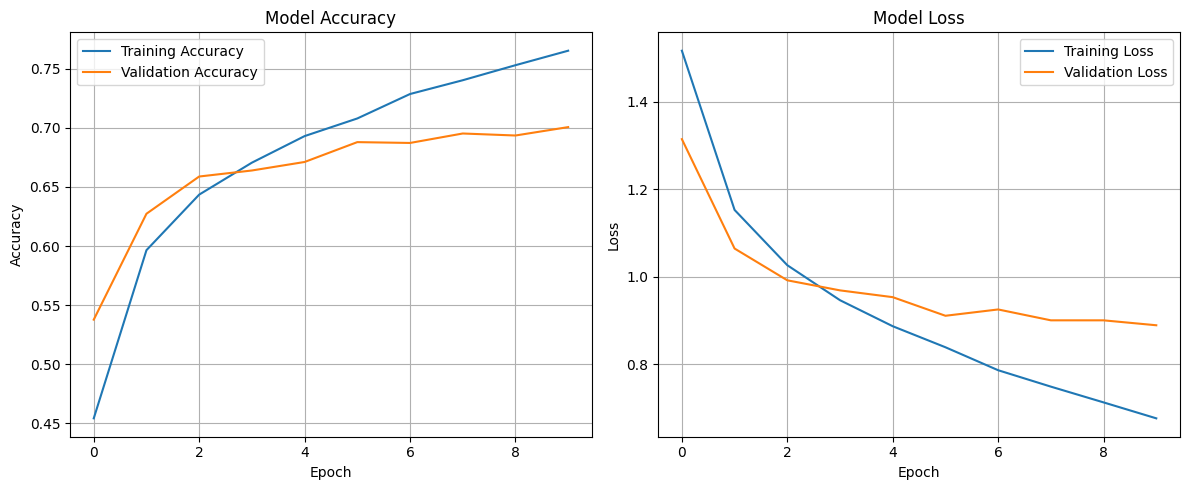

Training and validation accuracy/loss plots displayed.


In [24]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("Training and validation accuracy/loss plots displayed.")

In [25]:
num_sample_images = 10
sample_test_images = x_test_normalized[:num_sample_images]
sample_test_labels = y_test[:num_sample_images]

# Make predictions
predictions_probabilities = model.predict(sample_test_images)

# Convert probabilities to predicted class labels
predicted_labels = np.argmax(predictions_probabilities, axis=1)

print(f"Predictions made for {num_sample_images} sample test images.")
print(f"Shape of prediction probabilities: {predictions_probabilities.shape}")
print(f"Predicted class labels: {predicted_labels}")
print(f"True class labels: {sample_test_labels.flatten()}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
Predictions made for 10 sample test images.
Shape of prediction probabilities: (10, 10)
Predicted class labels: [3 8 8 0 4 6 1 6 3 1]
True class labels: [3 8 8 0 6 6 1 6 3 1]


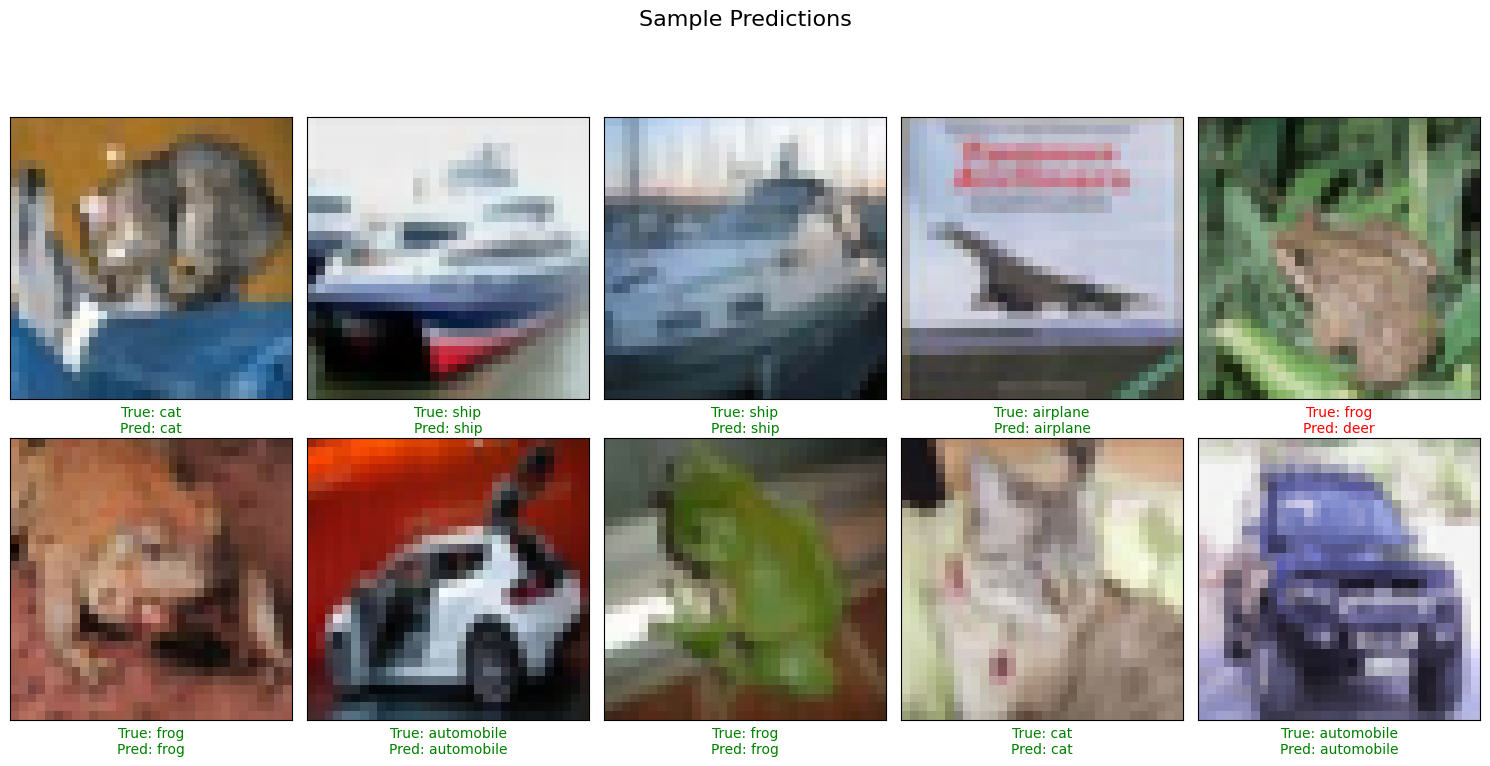

Sample predictions visualized with true and predicted labels.


In [27]:
plt.figure(figsize=(15, 8))
plt.suptitle('Sample Predictions', fontsize=16)

for i in range(num_sample_images):
    plt.subplot(2, 5, i + 1) # Arrange in 2 rows, 5 columns
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Display the image
    plt.imshow(x_test[i]) # Use original x_test for display, not normalized

    true_label = class_names[sample_test_labels[i][0]]
    predicted_label = class_names[predicted_labels[i]]

    # Color the label based on correctness
    color = 'green' if predicted_labels[i] == sample_test_labels[i][0] else 'red'

    plt.xlabel(f"True: {true_label}\nPred: {predicted_label}", color=color)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print("Sample predictions visualized with true and predicted labels.")

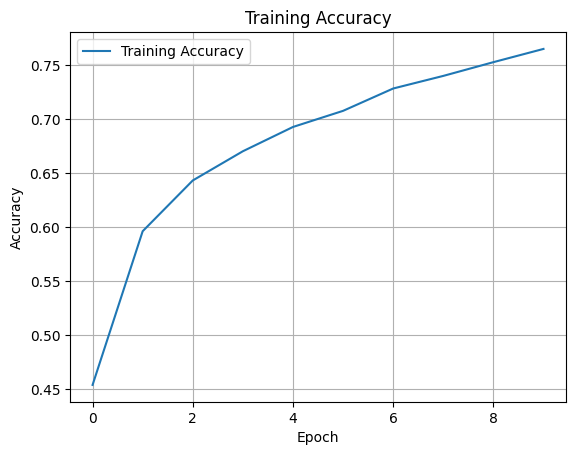

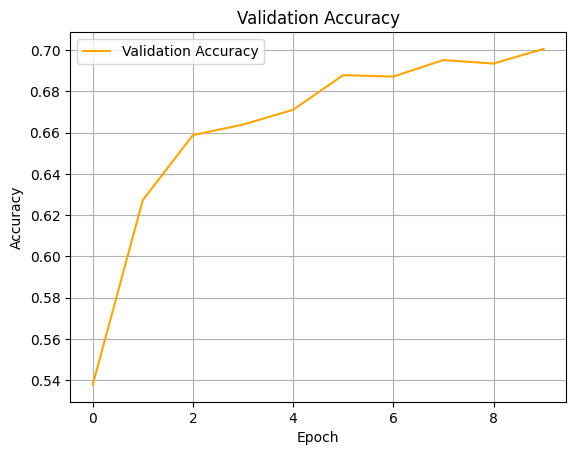

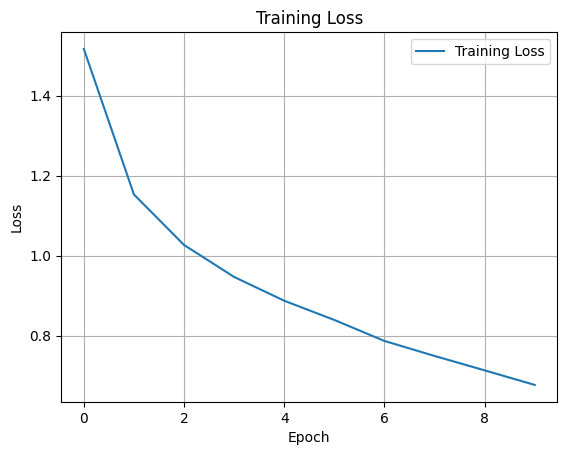

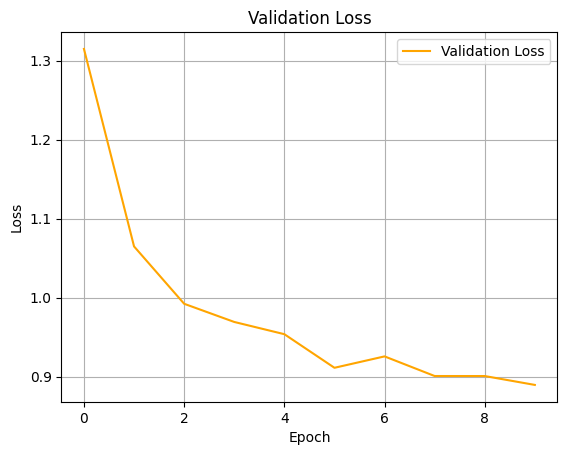

In [28]:
fig, ax = plt.subplots()
ax.plot(history.history['accuracy'], label='Training Accuracy')
ax.set_title('Training Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True)
plt.savefig('training_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots()
ax.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax.set_title('Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True)
plt.savefig('validation_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots()
ax.plot(history.history['loss'], label='Training Loss')
ax.set_title('Training Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots()
ax.plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax.set_title('Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)
plt.savefig('validation_loss.png', dpi=150, bbox_inches='tight')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step
              precision    recall  f1-score   support

    airplane       0.70      0.78      0.74      1000
  automobile       0.84      0.79      0.81      1000
        bird       0.58      0.63      0.60      1000
         cat       0.48      0.56      0.52      1000
        deer       0.75      0.56      0.64      1000
         dog       0.59      0.62      0.61      1000
        frog       0.71      0.83      0.77      1000
       horse       0.89      0.65      0.75      1000
        ship       0.79      0.82      0.81      1000
       truck       0.80      0.75      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



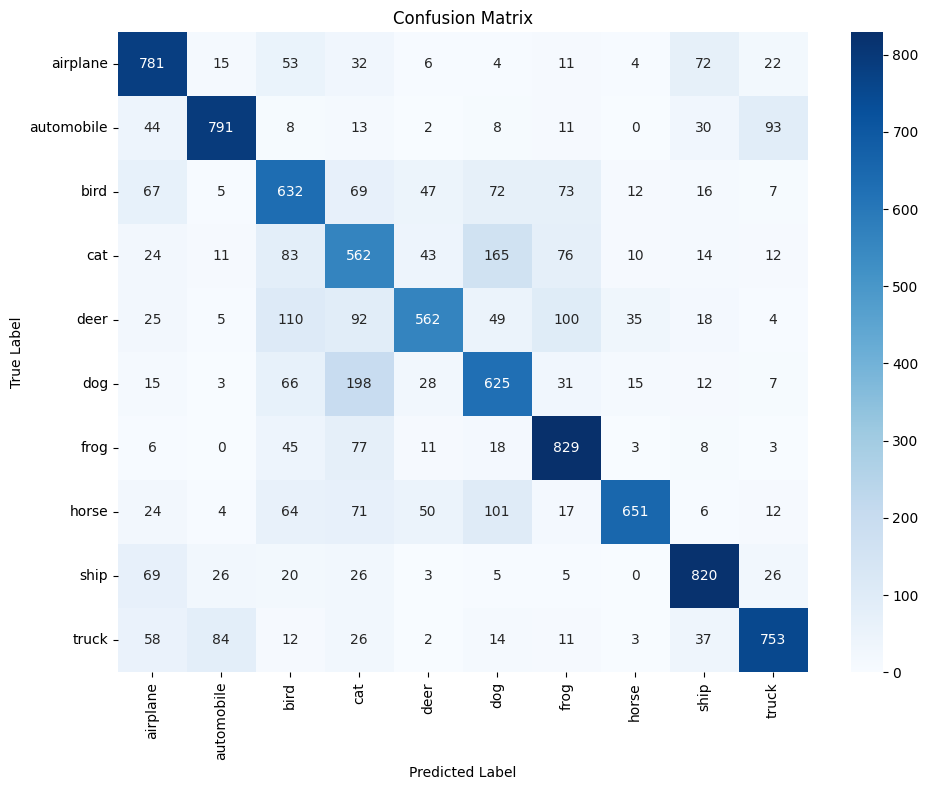

In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred_probs = model.predict(x_test_normalized)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.4452 - loss: 1.5609 - val_accuracy: 0.5406 - val_loss: 1.3353
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 42ms/step - accuracy: 0.5608 - loss: 1.2526 - val_accuracy: 0.5514 - val_loss: 1.2687
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.6022 - loss: 1.1414 - val_accuracy: 0.5895 - val_loss: 1.1565
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.6272 - loss: 1.0747 - val_accuracy: 0.5923 - val_loss: 1.1570
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.6488 - loss: 1.0171 - val_accuracy: 0.6167 - val_loss: 1.1135
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 36ms/step - accuracy: 0.4320 - loss: 1.5936 - val_accuracy: 0.5140 - val_loss: 1.3745
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step - accuracy: 0.5474 - loss: 1.2924 - val_accuracy: 0.5571 - val_loss: 1.2451
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - accuracy: 0.5838 - loss: 1.1955 - val_accu

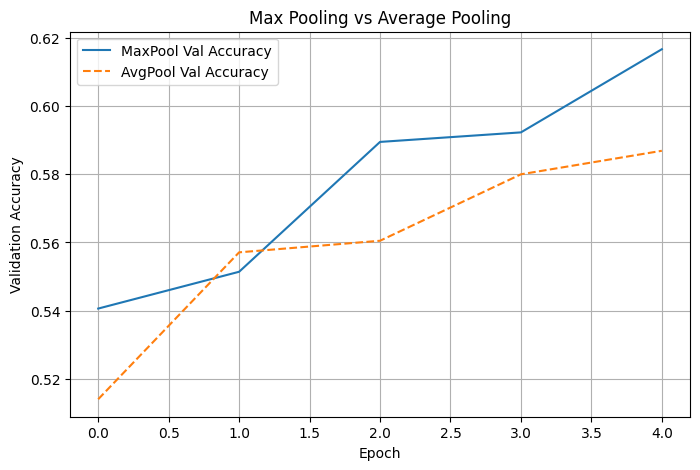

In [31]:
model_maxpool = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_avgpool = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.AveragePooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_maxpool.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_avgpool.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

hist_max = model_maxpool.fit(x_train_normalized, y_train_one_hot, epochs=5,
                              batch_size=64, validation_data=(x_test_normalized, y_test_one_hot), verbose=1)
hist_avg = model_avgpool.fit(x_train_normalized, y_train_one_hot, epochs=5,
                              batch_size=64, validation_data=(x_test_normalized, y_test_one_hot), verbose=1)

loss_max, acc_max = model_maxpool.evaluate(x_test_normalized, y_test_one_hot, verbose=0)
loss_avg, acc_avgpool = model_avgpool.evaluate(x_test_normalized, y_test_one_hot, verbose=0)

print(f"MaxPooling  — Test Accuracy: {acc_max:.4f}, Test Loss: {loss_max:.4f}")
print(f"AvgPooling  — Test Accuracy: {acc_avgpool:.4f}, Test Loss: {loss_avg:.4f}")

plt.figure(figsize=(8,5))
plt.plot(hist_max.history['val_accuracy'], label='MaxPool Val Accuracy')
plt.plot(hist_avg.history['val_accuracy'], label='AvgPool Val Accuracy', linestyle='--')
plt.title('Max Pooling vs Average Pooling')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('pooling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

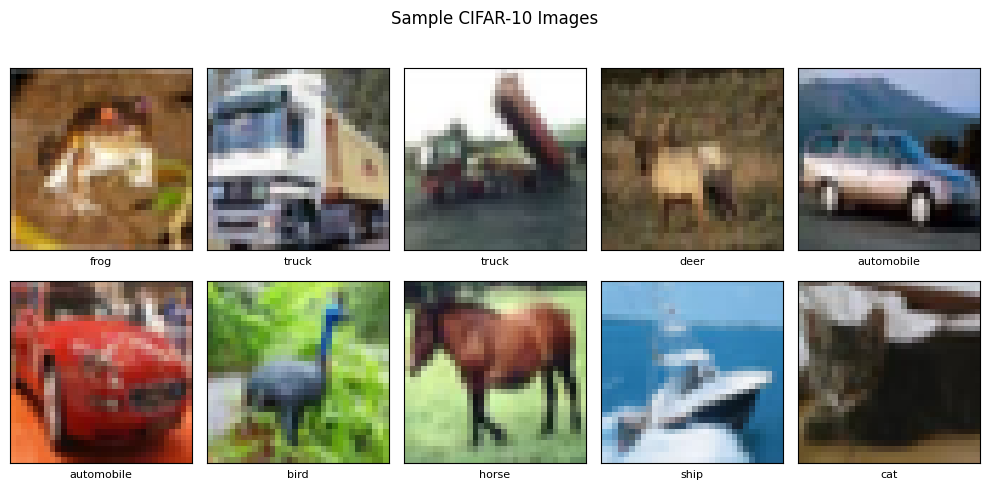

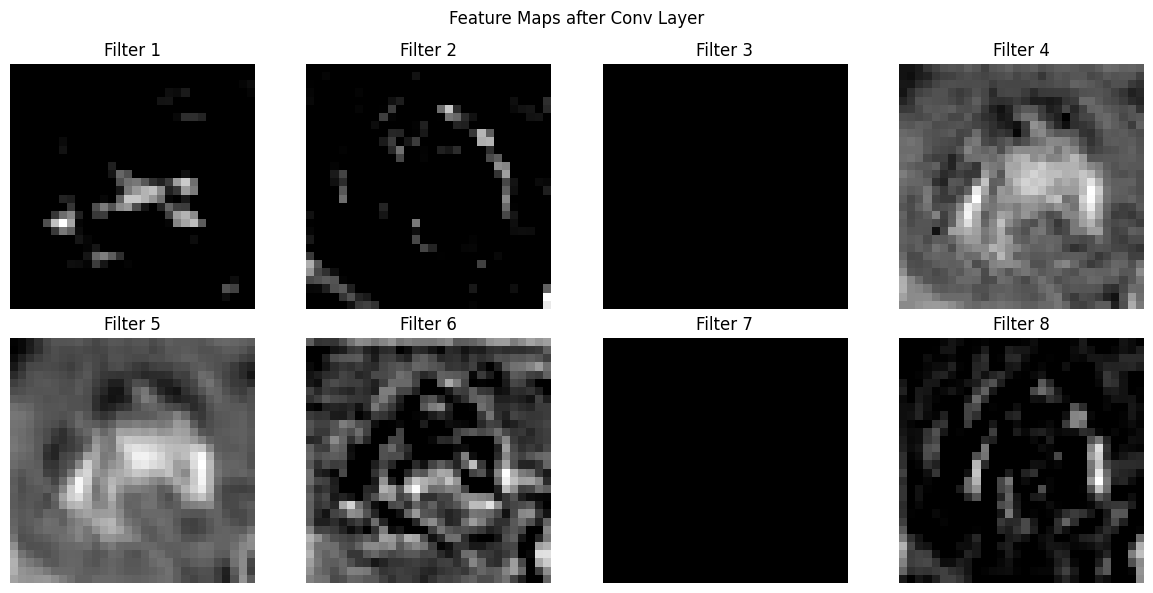

In [32]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]], fontsize=8)
plt.suptitle('Sample CIFAR-10 Images')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='gray')
    plt.title(f'Filter {i+1}')
    plt.axis('off')
plt.suptitle('Feature Maps after Conv Layer')
plt.tight_layout()
plt.savefig('feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()